# Sales Performance Dashboard & Business Insights

## Project Objective

The objective of this project is to analyze retail sales data to identify sales trends, regional performance, customer purchasing behavior, and product profitability. The project uses Python, MySQL, and Power BI to generate business insights and build an interactive sales dashboard for decision-making.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_csv("../Dataset/Sample - Superstore.csv", encoding="latin1")

In [4]:
# Display the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# Number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (9994, 21)


In [6]:
# Display all column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [8]:
# Check missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [9]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
# Summary statistics
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [11]:
# Display data types
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Data cleaning

In [13]:
# Convert Order Date and Ship Date to datetime

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print("Date columns converted successfully!")

Date columns converted successfully!


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [15]:
# Create new features

df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()

# Calculate shipping duration
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,7


# Exploratory Data Analysis (EDA)

The objective of EDA is to analyze sales performance, profitability, customer behavior, and regional trends to generate actionable business insights.

In [16]:
# Total Sales

total_sales = df["Sales"].sum()

print(f"Total Sales : ${total_sales:,.2f}")

Total Sales : $2,297,200.86


In [17]:
# Total Profit

total_profit = df["Profit"].sum()

print(f"Total Profit : ${total_profit:,.2f}")

Total Profit : $286,397.02


In [18]:
# Total Orders

total_orders = df["Order ID"].nunique()

print("Total Orders :", total_orders)

Total Orders : 5009


In [19]:
average_order_value = df["Sales"].mean()

print(f"Average Order Value : ${average_order_value:.2f}")

Average Order Value : $229.86


In [20]:
sales_by_category = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_category)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [21]:
profit_by_category = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_category)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [22]:
sales_by_region = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_region)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [23]:
profit_by_region = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_by_region)

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [24]:
sales_by_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_by_segment)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


In [25]:
monthly_sales = (
    df.groupby("Order Month Name")["Sales"]
      .sum()
)

print(monthly_sales)

Order Month Name
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart settings
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 6)

### Insight

Technology generated the highest sales among all product categories, followed by Furniture and Office Supplies.

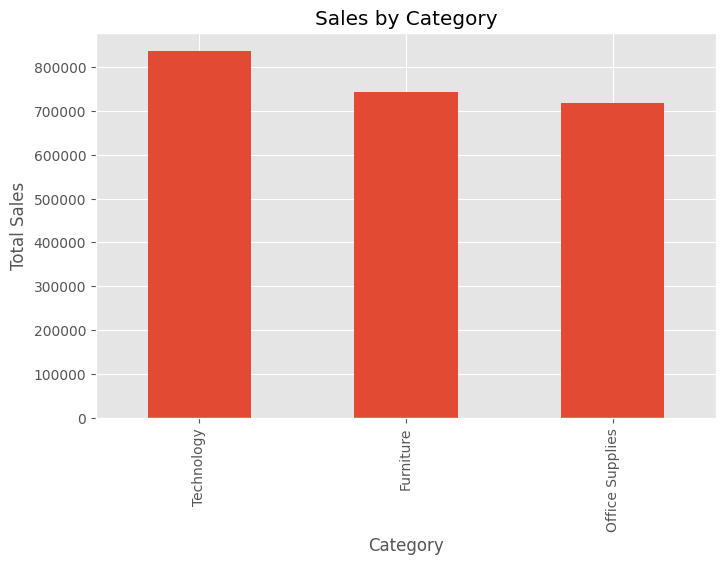

In [ ]:
#Which product category generates the highest sales?

sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_by_category.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

### Insight

Technology generated the highest sales among all product categories, followed by Furniture and Office Supplies.

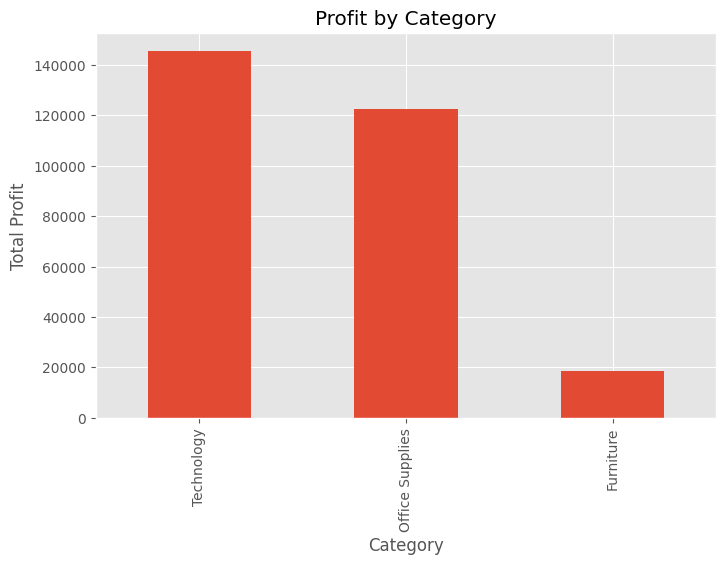

In [29]:
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
profit_by_category.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

### Insight

Technology contributed the highest overall profit, while Furniture generated comparatively lower profit despite high sales.

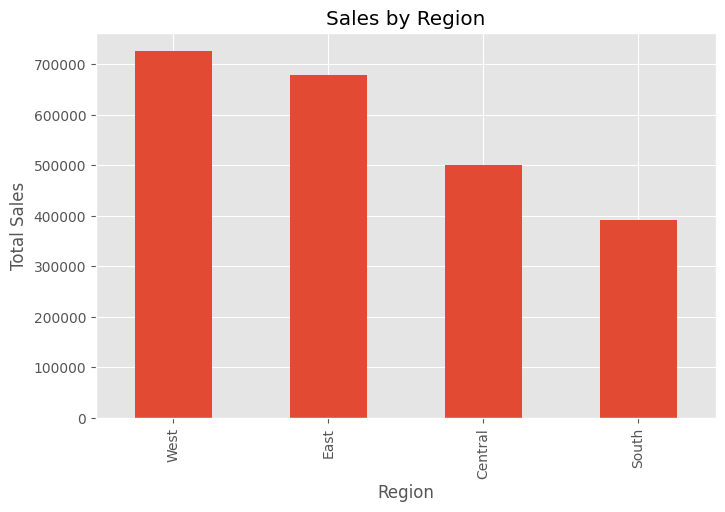

In [30]:
sales_by_region = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sales_by_region.plot(kind="bar")

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Insight

The West region recorded the highest sales, indicating stronger customer demand compared to other regions.

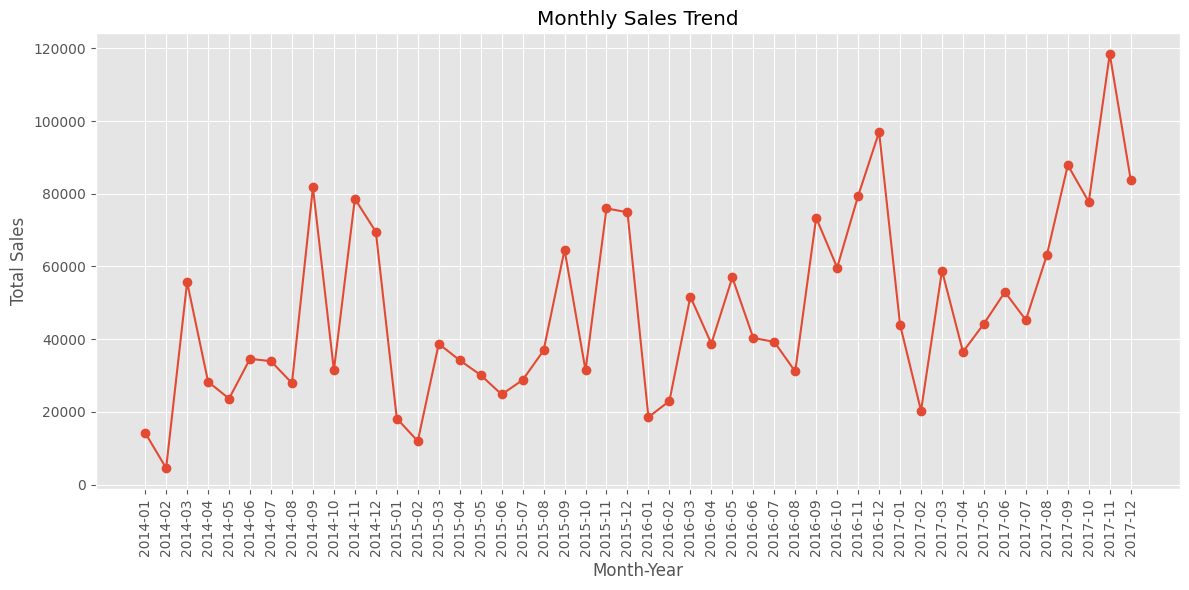

In [31]:
# Monthly Sales Trend

monthly_sales = (
    df.groupby(["Order Year", "Order Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Month-Year"] = (
    monthly_sales["Order Year"].astype(str)
    + "-"
    + monthly_sales["Order Month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Month-Year"],
    monthly_sales["Sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month-Year")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

The sales trend fluctuates across different months, indicating seasonal demand patterns. Identifying peak sales periods can help optimize inventory and marketing strategies.

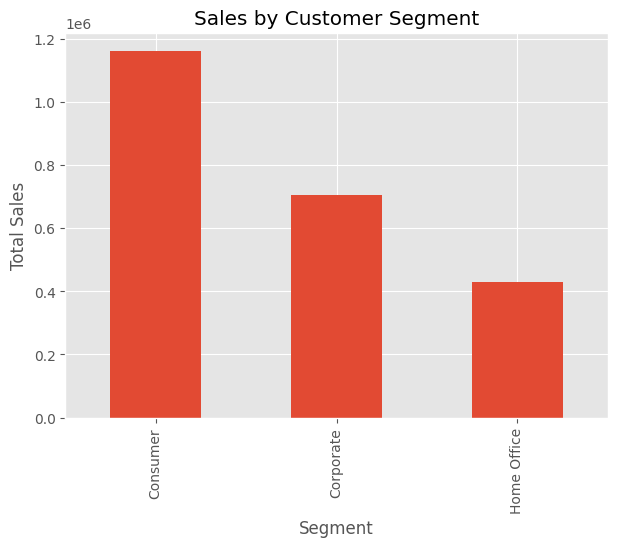

In [32]:
sales_segment = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(7,5))

sales_segment.plot(kind="bar")

plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")

plt.show()

The Consumer segment contributes the highest sales, making it the company's primary revenue source.

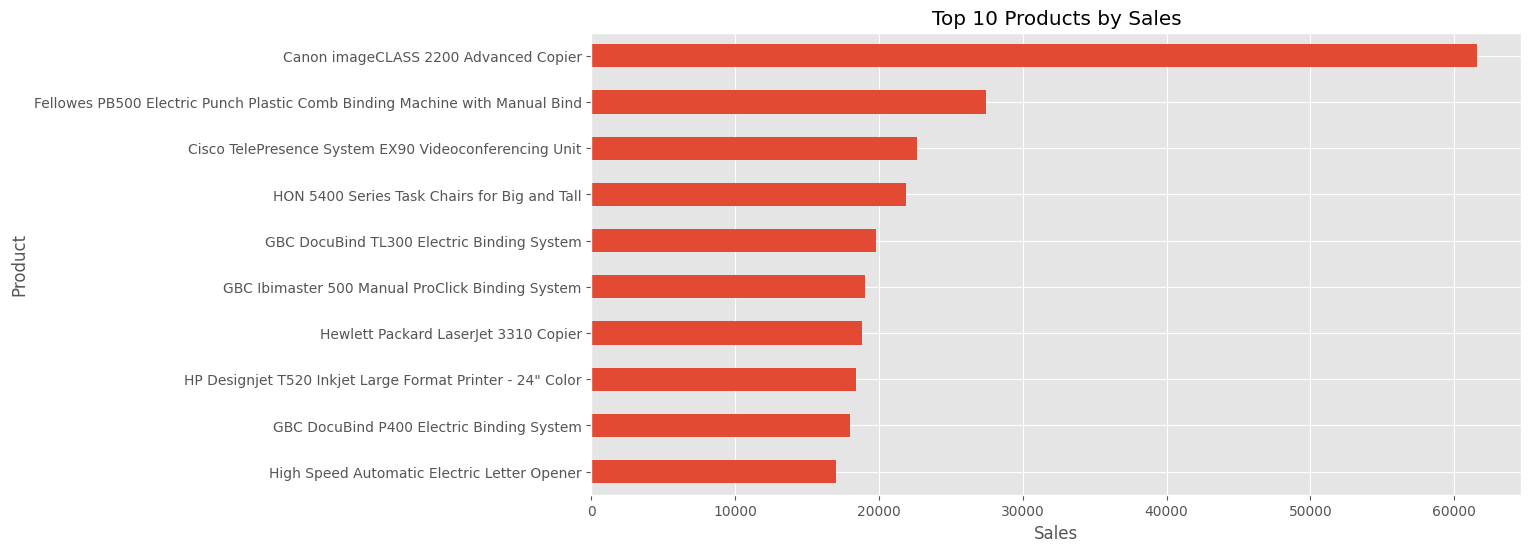

In [34]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

A small number of products contribute a significant portion of total sales. These products should receive priority in inventory management and promotional campaigns.

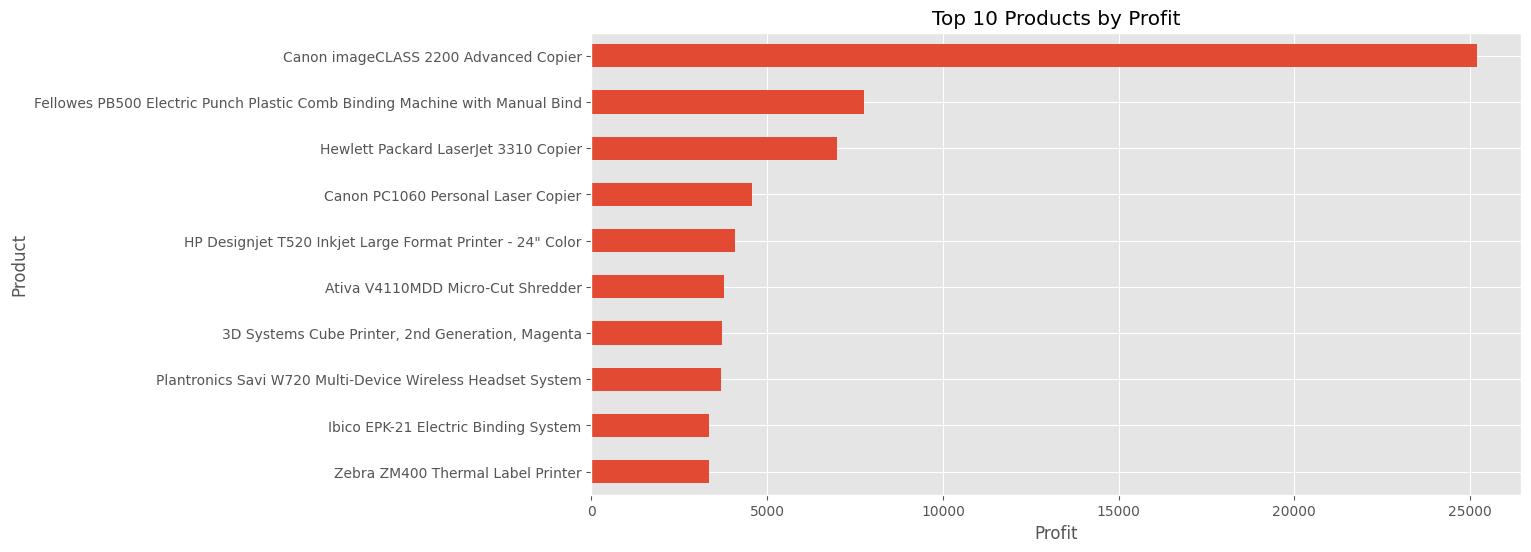

In [35]:
top_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_profit.plot(kind="barh")

plt.title("Top 10 Products by Profit")
plt.xlabel("Profit")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

The highest-selling products are not always the most profitable. Profitability should be considered alongside revenue when making business decisions.

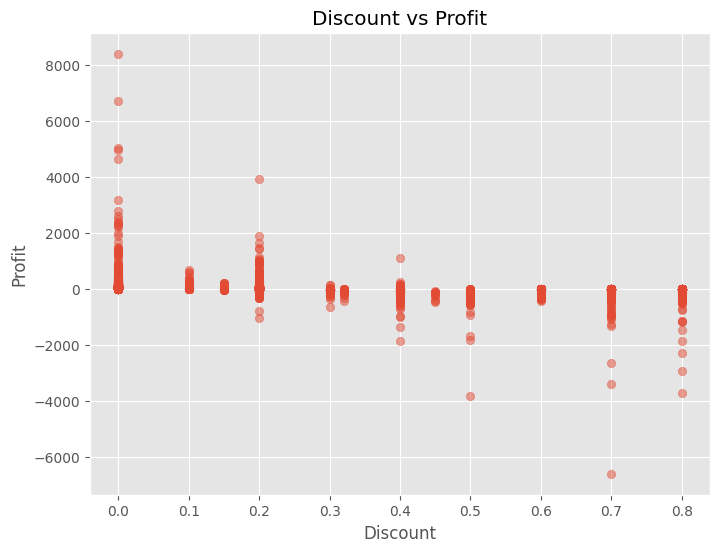

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

Higher discounts are generally associated with lower profits. This suggests that excessive discounting can negatively impact profitability.